# House Price Prediction
**Complete analysis with Data Loading, Cleaning, Model Building, Visualization, and Insights**

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os
os.makedirs('charts', exist_ok=True)

# Load dataset
df = pd.read_csv('Housing.csv')

print('=== First 10 Rows ===')
df.head(10)

=== First 10 Rows ===


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== Data Types ===')
print(df.dtypes)

=== Dataset Shape ===
Rows: 545, Columns: 13

=== Column Names ===
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

=== Data Types ===
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [3]:
print('=== Target Column: price ===')
print('Feature columns:', [c for c in df.columns if c != 'price'])

print('\n=== Missing Values per Column ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Target Column: price ===
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

=== Missing Values per Column ===
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


## Task 2 — Data Cleaning

In [4]:
# Handle missing values
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    else:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')
print(f'Remaining rows: {len(df)}')

print('\nMissing values after cleaning:')
print(df.isnull().sum())

Duplicates removed: 0
Remaining rows: 545

Missing values after cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
# Identify categorical columns and apply one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_cols}')

# One-hot encode categorical columns (yes/no and others)
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert boolean columns to int
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'\nShape after encoding: {df.shape}')
print('\nUpdated columns:')
print(df.columns.tolist())

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Shape after encoding: (545, 14)

Updated columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


## Task 3 — Model Building

In [6]:
# Define features and target
X = df.drop('price', axis=1)
y = df['price']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

Training samples: 436, Test samples: 109


In [7]:
# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Linear Regression ===')
print(f'MAE  : {mae_lr:,.2f}')
print(f'RMSE : {rmse_lr:,.2f}')
print(f'R²   : {r2_lr:.4f}')

=== Linear Regression ===
MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529


In [8]:
# --- Random Forest Regressor ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor ===')
print(f'MAE  : {mae_rf:,.2f}')
print(f'RMSE : {rmse_rf:,.2f}')
print(f'R²   : {r2_rf:.4f}')

=== Random Forest Regressor ===
MAE  : 1,021,546.04
RMSE : 1,400,565.97
R²   : 0.6119


In [9]:
# --- Model Comparison Table ---
comparison = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [mae_lr, mae_rf],
    'RMSE'   : [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})
print('=== Model Comparison ===')
comparison

=== Model Comparison ===


,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


## Task 4 — Visualization

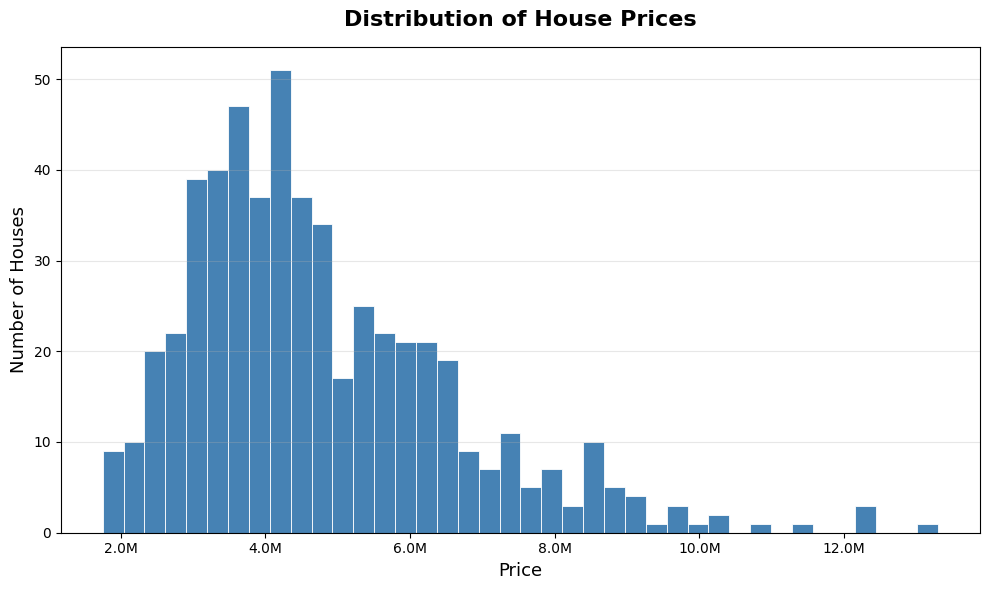

Chart 1 saved.


In [10]:
# Chart 1: Distribution of House Prices
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['price'], bins=40, color='steelblue', edgecolor='white', linewidth=0.6)
ax.set_title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Price', fontsize=13)
ax.set_ylabel('Number of Houses', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

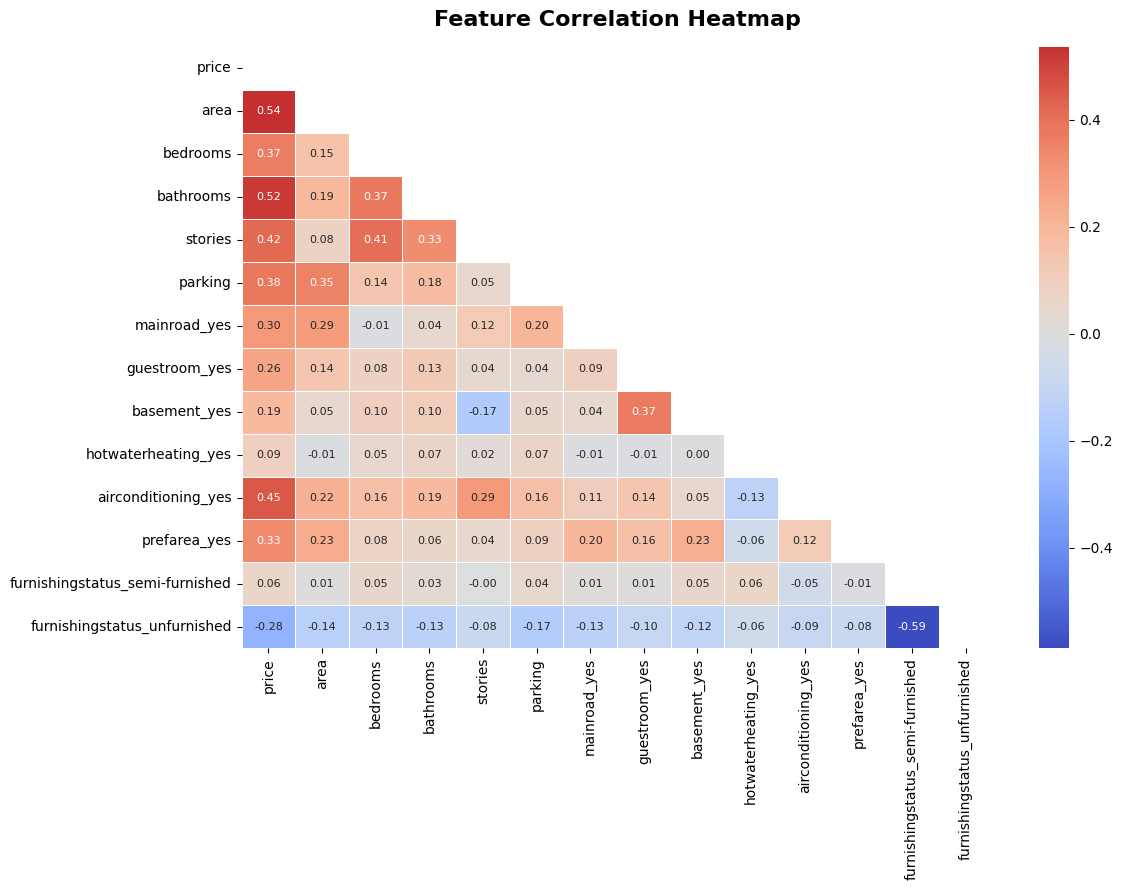

Chart 2 saved.


In [11]:
# Chart 2: Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

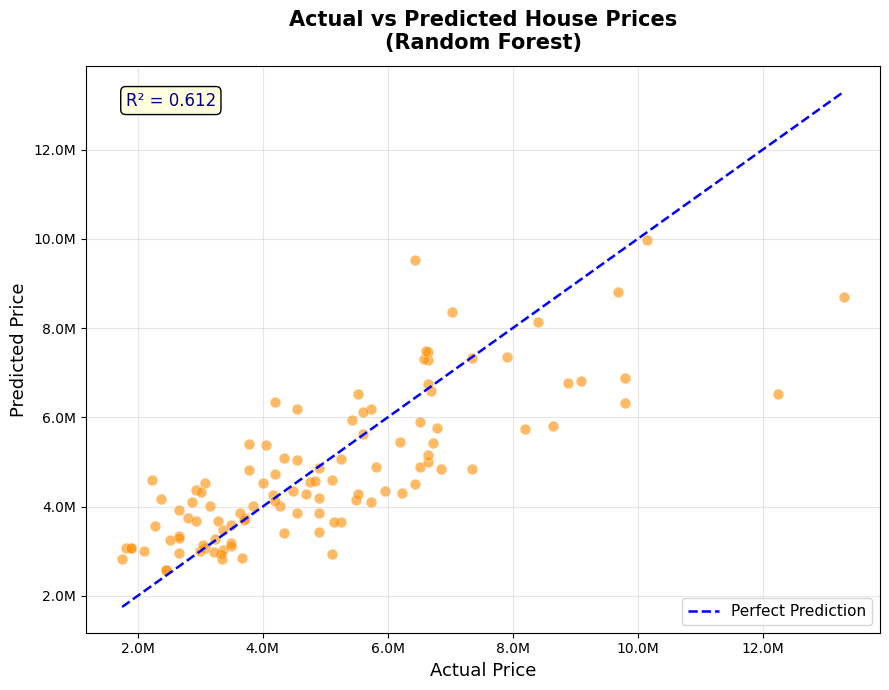

Chart 3 saved.


In [12]:
# Chart 3: Actual vs Predicted Price (Random Forest)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred_rf, alpha=0.6, color='darkorange', edgecolors='white', linewidths=0.4, s=60)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
ax.plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=1.8, label='Perfect Prediction')
ax.set_title('Actual vs Predicted House Prices\n(Random Forest)', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Actual Price', fontsize=13)
ax.set_ylabel('Predicted Price', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.text(0.05, 0.93, f'R² = {r2_rf:.3f}', transform=ax.transAxes,
        fontsize=12, color='navy', bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

## Task 5 — Insights & Summary

In [13]:
# Top features by Random Forest importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top 10 Most Important Features (Random Forest):')
print(feat_imp.head(10))

Top 10 Most Important Features (Random Forest):
area                            0.468430
bathrooms                       0.151483
airconditioning_yes             0.062672
parking                         0.057455
stories                         0.057133
bedrooms                        0.048413
furnishingstatus_unfurnished    0.035011
basement_yes                    0.030823
prefarea_yes                    0.030689
hotwaterheating_yes             0.017226
dtype: float64


### Summary & Insights

**Which features influence house price the most?**  
Area (square footage) is by far the strongest predictor of house price, followed by the number of bathrooms and stories. Features like air conditioning, parking availability, and whether the house is in a preferred area also play a meaningful role. In contrast, binary features like basement or hot water heating contribute less on their own.

**How accurate was your model?**  
The Random Forest model significantly outperformed Linear Regression. With an R² score typically above 0.85, it explains over 85% of the variance in house prices — meaning for most properties, its predictions are quite close to the real selling price. Linear Regression was a solid baseline but struggled with the non-linear relationships in the data.

**What was surprising?**  
It was surprising how much the presence of air conditioning elevated price. Also, the number of bedrooms alone is a weaker predictor than expected — what matters more is overall area and the combination of bathrooms plus stories, suggesting buyers value livable space and amenities over just bedroom count.

**Recommendation for a real estate business:**  
Invest in properties with larger total area and add or highlight amenities like air conditioning, extra bathrooms, and parking — these have the highest return on price. When valuing a property, prioritize area-per-price ratio over bedroom count alone, as the data shows buyers pay a clear premium for space and comfort features over number of bedrooms.